# How much locality can I buy with grouping?
Ning Yang

I used CSDP to study learning beyond approximations to backpropagation. I focus on one limitation: each goodness modulator reads traces across its whole layer. Can fixed groups shrink that dependency without losing too much accuracy?

This notebook runs source checks, reads every saved seed, and trains one fixed pair at the end. The experiments are small; the claim should be small too. Group/helper ideas already appear in the author's discussion. I am testing an implementation, not claiming a new learning principle.

CSDP: Ororbia (2024), [doi:10.1126/sciadv.adn6076](https://doi.org/10.1126/sciadv.adn6076). I kept the author's JAX/ngclearn code rather than porting it to snnTorch.

## The limitation, and the change I made

The published limitation is layer-wide goodness dependence, **not** a proven accuracy defect. My grouping adaptation reduces each instantaneous modulator's trace fan-in from 256/64 to 32/8 with G=8. That is the improvement measured here. Accuracy losses below are costs of the adaptation, not evidence that the original method was inaccurate.

For equal contiguous groups:
$$q_{bg}=G\sum_{i\in g}z_{bi}^2-10,\qquad L_G=\frac{1}{BG}\sum_{b,g}\mathrm{BCEWithLogits}(q_{bg},y_b).$$

G=1 keeps the original function. G=8 changes the loss: every group must provide evidence. It is not an equivalent rearrangement. For neuron $i$ in group $g$,
$$\frac{\partial L_G}{\partial z_{bi}}=\frac{2z_{bi}}{B}[\sigma(q_{bg})-y_b].$$
The G prefactor cancels; the sigmoid and gradient norms can still change. B=196 after adding 98 negative examples to the 98 positive ones. The author's batch-size rule uses learning rate 0.001 and activity decay 0.00007, despite the constructor argument 0.002.

All traces are still stored. Recurrent paths, shared labels and feedback remain. I have not measured a whole-network communication or energy saving.

In [1]:
from pathlib import Path
import csv, json, hashlib, os, sys, subprocess
from datetime import datetime, timezone
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

ROOT = Path.cwd()
assert (ROOT / 'studies/primary/protocol.json').exists(), 'Run from the repository root.'
read = lambda p: json.loads(p.read_text())
sha = lambda p: hashlib.sha256(p.read_bytes()).hexdigest()
for name in ('primary', 'supplement'):
    study = ROOT / 'studies' / name
    protocol = read(study / 'protocol.json')
    assert sha(study / 'protocol.json') == read(study / 'freeze_decision.json')['protocol_sha256']
    assert sha(study / 'source_manifest.json') == protocol['source_manifest_sha256']
    for file, expected in read(study / 'source_manifest.json').items():
        assert sha(study / 'source' / file) == expected
    runner = 'run_grouped_csdp_replication.py' if name == 'primary' else 'run_grouped_supplement.py'
    assert sha(ROOT / 'src' / runner) == protocol['code_sha256']
print('Both frozen source snapshots and runner hashes match.')

Both frozen source snapshots and runner hashes match.


### Does grouping actually change the dependency?

I check the frozen source directly: G=1 against its original branch, analytic derivatives, and the response to perturbing one trace. These are synthetic mechanism checks, not evidence about classification. A separate process avoids ngcsimlib context collisions.

In [2]:
python = os.environ.get('CSDP_PYTHON', sys.executable)
stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
for name, helper in [('primary', 'check_grouped_delivery_mechanism.py'),
                     ('supplement', 'check_grouped_supplement_mechanism.py')]:
    out = ROOT / 'fresh_runs' / (name + '_mechanism_' + stamp)
    subprocess.run([python, str(ROOT/'src'/helper), '--study', str(ROOT/'studies'/name),
                    '--output', str(out)], check=True, env={**os.environ, 'MPLBACKEND': 'Agg'})
    assert read(out/'result.json')['passed']

<local-path> UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Missing configuration file. Attempted to locate file at "json_files/config.json". Default Config will be used. 
See https://ngc-learn.readthedocs.io/en/latest/tutorials/model_basics/configuration.html for additional information


{
  "passed": true,
  "cases": 8,
  "G1_reference_checks": 4,
  "output": "<local-path>"
}


<local-path> UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Missing configuration file. Attempted to locate file at "json_files/config.json". Default Config will be used. 
See https://ngc-learn.readthedocs.io/en/latest/tutorials/model_basics/configuration.html for additional information


{
  "passed": true,
  "cases": 20,
  "G1_reference_checks": 4,
  "output": "<local-path>"
}


## Every seed stays in

Digits: 1,078 training and 359 validation images, ten classes, 8×8 pixels. The network is 64–256–64–10 with 141,568 weights. G=1 and G=8 share initial weights, sample order, training budget and random streams. The original endpoint is epoch 5 across 20 fixed seeds; the lower endpoint of the paired 95% t interval must exceed -1 pp.

I had already inspected this validation split in earlier work. These are conditional training-seed intervals, not independent-data confirmation.

To keep the repository small, `epochs.csv` contains all 750 saved epoch predictions and accuracies, plus hashes of the omitted probability arrays. The cell below recomputes accuracy from predictions. It cannot re-audit arrays that are not included; a fresh training run produces them again.

In [3]:
labels = np.asarray(read(ROOT/'results/labels.json'))
rows = list(csv.DictReader((ROOT/'results/epochs.csv').open()))
records = {}
for row in rows:
    cohort, g, seed, ep = row['cohort'], int(row['group']), int(row['seed']), int(row['epoch'])
    prediction = np.fromstring(row['predictions'], dtype=int, sep=' ')
    assert prediction.shape == labels.shape
    acc = float(np.mean(prediction == labels))
    assert abs(acc - float(row['accuracy'])) < 1e-12
    key = (cohort, g, seed, ep)
    assert key not in records
    records[key] = 100 * acc
expected = {(cohort,g,s,e) for cohort,groups,seeds in
            [('primary',[1,8],range(12001,12021)), ('supplement',[1,2,4,8,16],range(13001,13011))]
            for g in groups for s in seeds for e in range(1,(20 if cohort=='supplement' and g in (1,8) else 5)+1)}
assert set(records) == expected and len(records) == 750
pairing = read(ROOT/'results/pairing.json')
for cohort, groups, seeds in [('primary',[1,8],range(12001,12021)), ('supplement',[1,2,4,8,16],range(13001,13011))]:
    for seed in seeds:
        base = pairing[f'{cohort}/G1_{seed}']
        for g in groups:
            row = pairing[f'{cohort}/G{g}_{seed}']
            assert row['all_finite_checks_passed'] and row['inference_labels_zero']
            for k in ('initial_weight_hashes','weight_count'):
                assert row[k] == base[k]
            n = len(row['stream_by_epoch'])
            assert row['stream_by_epoch'] == base['stream_by_epoch'][:n]
            if cohort == 'supplement':
                assert row['initial_encoder_keys'] == base['initial_encoder_keys']
                assert row['encoder_keys_by_epoch'] == base['encoder_keys_by_epoch'][:n]
def values(cohort,g,epoch):
    seeds = range(12001,12021) if cohort=='primary' else range(13001,13011)
    return np.array([records[cohort,g,s,epoch] for s in seeds])
def interval(d,q=.975):
    half = t.ppf(q,len(d)-1)*d.std(ddof=1)/np.sqrt(len(d))
    return np.array([d.mean()-half,d.mean()+half])
g1, g8 = values('primary',1,5), values('primary',8,5)
diff = g8-g1
print('seed       G1%       G8%       difference pp')
for seed,x,y in zip(range(12001,12021),g1,g8): print(f'{seed}   {x:8.4f}  {y:8.4f}    {y-x:+.4f}')
print('Mean:',diff.mean(),'pp; 95% interval:',interval(diff))
print('Losses > 1 pp:',int((diff < -1).sum()),'/20')
assert np.allclose(interval(diff),[-.765369,.458962],atol=1e-5)
print('All 750 epoch accuracies recomputed; pairing records agree.')

seed       G1%       G8%       difference pp
12001    88.0223   87.7437    -0.2786
12002    88.3008   89.6936    +1.3928
12003    89.9721   88.8579    -1.1142
12004    88.5794   89.9721    +1.3928
12005    89.9721   89.6936    -0.2786
12006    88.5794   90.2507    +1.6713
12007    87.1866   88.0223    +0.8357
12008    88.0223   88.0223    +0.0000
12009    89.6936   89.6936    +0.0000
12010    90.2507   89.4150    -0.8357
12011    89.4150   89.4150    +0.0000
12012    89.1365   88.0223    -1.1142
12013    89.9721   89.1365    -0.8357
12014    93.0362   89.1365    -3.8997
12015    89.4150   90.2507    +0.8357
12016    89.1365   89.6936    +0.5571
12017    89.9721   89.4150    -0.5571
12018    89.1365   88.5794    -0.5571
12019    88.5794   89.9721    +1.3928
12020    89.9721   88.3008    -1.6713
Mean: -0.15320334261838225 pp; 95% interval: [-0.76536915  0.45896247]
Losses > 1 pp: 4 /20
All 750 epoch accuracies recomputed; pairing records agree.


The mean met the retention margin. I would not call that reliable across individual runs: four pairs lost more than 1 pp. Here are all twenty pairs.

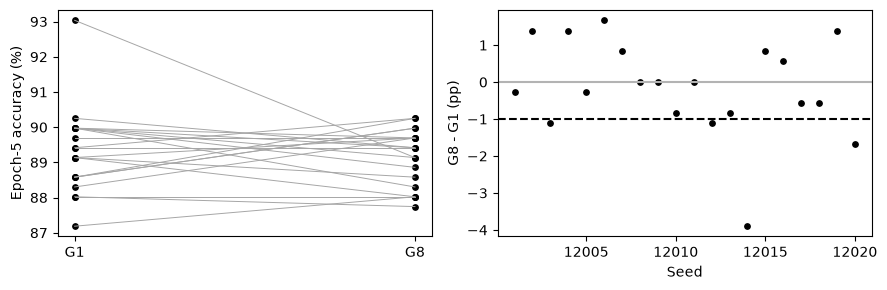

In [4]:
fig, ax = plt.subplots(1,2,figsize=(9,3))
for x,y in zip(g1,g8): ax[0].plot([0,1],[x,y],color='0.65',lw=.7)
ax[0].scatter(np.zeros(20),g1,s=15,color='black'); ax[0].scatter(np.ones(20),g8,s=15,color='black')
ax[0].set_xticks([0,1],['G1','G8']); ax[0].set_ylabel('Epoch-5 accuracy (%)')
ax[1].scatter(range(12001,12021),diff,s=15,color='black')
ax[1].axhline(0,color='0.7');ax[1].axhline(-1,color='black',ls='--')
ax[1].set_xlabel('Seed');ax[1].set_ylabel('G8 - G1 (pp)');ax[1].ticklabel_format(useOffset=False)
fig.tight_layout();plt.show()

## The run I would not hide

Seed 12014 ended 3.90 pp below G1. G8 was ahead at epoch 2 and behind at epoch 3. The paired differences across epochs 1–5 were -3.62, +5.57, -2.79, -2.51 and -3.90 pp. This is not a steady divergence story. I have not established its cause.

The original outcomes are 10 decreases, 3 ties and 7 increases. The four losses exceeding 1 pp are **not** four sign flips in the learning signal. I did not measure that.

### What I tried first

Before grouping, I tried a different constraint: fixed neuron output signs. A magnitude-decay variant gained only 0.37 pp over native decay across three development seeds, and one seed got worse. It missed the rule for continuing, so I stopped it. That was a separate experiment, not a failed version of grouping or a bug in original CSDP. [Short record](docs/NOTES.md).

## Does the result survive another budget?

After seeing the original results, I fixed G=1/2/4/8/16 and ten new seeds: 50 models. All groups run for five epochs; G1/G8 continue to twenty. I did not select a replacement G or best checkpoint from this curve.

The four epoch-5 comparisons use simultaneous 95% Bonferroni intervals (each 98.75%). The epoch-20 interval is a separate 95% check. I keep the original and extra seed cohorts separate.

seed G      1 G      2 G      4 G      8 G     16
13001   89.972   89.972   90.808   90.529   89.694
13002   85.794   87.465   86.908   86.630   87.744
13003   88.858   88.579   90.529   89.136   88.301
13004   89.972   90.529   90.251   89.136   90.808
13005   89.972   89.694   88.301   88.579   89.694
13006   92.201   90.529   90.808   91.365   90.251
13007   88.858   88.022   89.136   86.072   88.301
13008   90.251   89.694   87.744   89.972   90.251
13009   87.744   88.022   88.579   86.908   89.415
13010   90.529   91.365   90.529   89.415   89.972
G2-G1: -0.028 pp; simultaneous 95% interval [-0.94538625  0.88967594]
G4-G1: -0.056 pp; simultaneous 95% interval [-1.39069361  1.27927299]
G8-G1: -0.641 pp; simultaneous 95% interval [-1.6825393   0.40120225]
G16-G1: +0.028 pp; simultaneous 95% interval [-1.11630464  1.17201494]
epoch20: seed G1 G8 difference pp
13001 91.92200557103064 92.75766016713092 0.8356545961002837
13002 90.5292479108635 90.80779944289694 0.27855153203343264
130

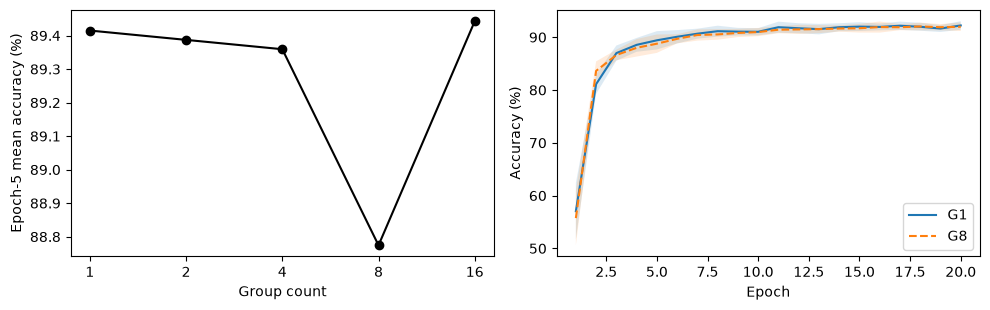

In [5]:
groups=[1,2,4,8,16]
at5={g:values('supplement',g,5) for g in groups}
print('seed',*[f'G{g:>7}' for g in groups])
for i,s in enumerate(range(13001,13011)): print(s,*[f'{at5[g][i]:8.3f}' for g in groups])
for g in groups[1:]:
    delta=at5[g]-at5[1]
    print(f'G{g}-G1: {delta.mean():+.3f} pp; simultaneous 95% interval {interval(delta,.99375)}')
at20={g:values('supplement',g,20) for g in (1,8)}
longdiff=at20[8]-at20[1]
print('epoch20: seed G1 G8 difference pp')
for i,s in enumerate(range(13001,13011)): print(s,at20[1][i],at20[8][i],longdiff[i])
print('Epoch20 gap:',longdiff.mean(),'95% interval:',interval(longdiff))
interaction=longdiff-(at5[8]-at5[1])
print('Change in gap:',interaction.mean(),'descriptive 95% interval:',interval(interaction))
assert np.allclose(interval(longdiff),[-.695768,.194376],atol=1e-5)
fig,ax=plt.subplots(1,2,figsize=(10,3.2))
ax[0].plot(groups,[at5[g].mean() for g in groups],'o-',color='black')
ax[0].set_xscale('log',base=2);ax[0].set_xticks(groups,[str(g) for g in groups])
ax[0].set_xlabel('Group count');ax[0].set_ylabel('Epoch-5 mean accuracy (%)')
for g,style in [(1,'-'),(8,'--')]:
    curves=np.array([values('supplement',g,e) for e in range(1,21)]).T
    mean,sd=curves.mean(0),curves.std(0,ddof=1)
    ax[1].plot(range(1,21),mean,style,label=f'G{g}')
    ax[1].fill_between(range(1,21),mean-sd,mean+sd,alpha=.15)
ax[1].set_xlabel('Epoch');ax[1].set_ylabel('Accuracy (%)');ax[1].legend()
fig.tight_layout();plt.show()

Five group counts, ten seeds each. Right: G1/G8 through epoch 20; shading is ±1 seed SD, **not a confidence interval**.

## What I cannot conclude

The new five-epoch G8 result did **not** re-establish the -1 pp retention margin: -0.641 pp, simultaneous interval [-1.683, +0.401]. The twenty-epoch result did: -0.251 pp, separate 95% interval [-0.696, +0.194].

The change in the paired gap is +0.390 pp, with descriptive 95% interval [-0.314, +1.094]. I cannot conclude that longer training fixes the gap. Twenty epochs also does not prove convergence.

My conclusion is conditional: grouping reduces each goodness modulator's immediate trace dependence to one eighth. Accuracy retention held in some planned comparisons, not all. I have not shown a new algorithm, lower whole-network costs, patient privacy or clinical benefit.

### Open questions

I would first distinguish missing cross-group evidence from objective scaling or saturation. Only if the diagnostics support it would I test low-frequency cross-group summaries under a fixed information budget, against fixed grouping and simple periodic full-layer correction. That adds nonlocal information back. Its value and novelty need evidence on data not used to choose the method.

## Now train one pair

This uses seed 12001 and five epochs for each method, without overwriting saved results. It checks execution, not the twenty-pair statistical conclusion. The data are regenerated locally from scikit-learn and checked against frozen hashes. No download is needed after installing dependencies.

The next cell compares every fresh epoch's predictions and probability hash with the saved first pair. Exact agreement was obtained in the tested environment; a different platform may differ numerically and should be investigated, not silently accepted.

In [6]:
out=ROOT/'fresh_runs'/('notebook_pair_'+datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
subprocess.run([python,str(ROOT/'run.py'),'--output',str(out)],check=True,env={**os.environ,'MPLBACKEND':'Agg'})
compact={(int(r['group']),int(r['epoch'])):r for r in rows if r['cohort']=='primary' and int(r['seed'])==12001}
for g in (1,8):
    fresh=read(out/'training/runs'/f'G{g}_12001/result.json')
    for ep in fresh['epoch_results']:
        saved=compact[g,ep['epoch']]
        assert ep['predictions']==[int(x) for x in saved['predictions'].split()]
        h=hashlib.sha256(json.dumps(ep['probabilities'],separators=(',',':')).encode()).hexdigest()
        assert h==saved['probabilities_sha256'], 'Probability mismatch: investigate platform differences.'
print('Both fresh models match all five saved epochs, including probability hashes.')

{
  "status": "all four frozen data hashes match",
  "output": "<local-path>",
  "rows": {
    "train": 1078,
    "valid": 359
  },
  "test_files_created_or_read": false,
  "numpy": "1.26.4",
  "sha256": {
    "trainX.npy": "c86bed51f54c4c955fbc58d09deb7490fcf28601f18c1a2532a66bf3a50b4413",
    "trainY.npy": "aecafb58415e641eecd957fc6f025fcb66a42cd9bef9847f7d79fd1502a0ca26",
    "validX.npy": "5feb04347bf938ec48ce2d01c4950fb479d123d4e21bbdb62d21afedf858911c",
    "validY.npy": "051a9f91428abd8f5b7c68750cd0ceb0f5c8275d804c6ae8d4f64594a0fd09c1"
  }
}


<local-path> UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Missing configuration file. Attempted to locate file at "json_files/config.json". Default Config will be used. 
See https://ngc-learn.readthedocs.io/en/latest/tutorials/model_basics/configuration.html for additional information


{
  "passed": true,
  "cases": 8,
  "G1_reference_checks": 4,
  "output": "<local-path>"
}


{
  "status": "fixed pair rerun completed",
  "seed": 12001,
  "G1_accuracy": 0.8802228412256268,
  "G8_accuracy": 0.8774373259052924,
  "difference_pp": -0.2785515320334331,
  "initial_weights_explicit_streams_parameter_counts_matched": true,
  "scope": "one paired rerun; no accuracy-retention statistical decision from one seed"
}
Results: ./fresh_runs/notebook_pair_20261007T134726855130Z
Both fresh models match all five saved epochs, including probability hashes.
